===== DATASET OVERVIEW =====
Rows    : 26,305
Columns : 6

===== COLUMNS =====
['timestamp', 'cpu_utilization', 'memory_usage', 'storage_usage', 'workload', 'Resource Allocation']

===== DATE RANGE =====
Start: 2022-01-01 00:00:00
End  : 2025-01-01 00:00:00

===== DATA TYPES =====
timestamp              datetime64[us]
cpu_utilization               float64
memory_usage                  float64
storage_usage                 float64
workload                      float64
Resource Allocation           float64
dtype: object

===== FIRST 5 ROWS =====


,timestamp,cpu_utilization,memory_usage,storage_usage,workload,Resource Allocation
0,2024-05-15 06:00:00,93.667656,65.739742,81.202149,100.00000,76.398051
1,2022-03-20 00:00:00,NaN,45.771232,56.178079,96.20153,52.783747
2,2024-03-31 02:00:00,66.270283,85.537221,61.594411,100.00000,71.699889
3,2022-10-05 07:00:00,50.305590,55.492008,100.419747,100.00000,69.456805
4,2022-07-18 08:00:00,58.567954,77.339342,60.446444,100.00000,66.624977



===== MISSING VALUES =====


,Missing Count,Missing %
timestamp,0,0.00
cpu_utilization,2819,10.72
memory_usage,3071,11.67
storage_usage,3306,12.57
workload,0,0.00
Resource Allocation,2572,9.78



===== SUMMARY STATISTICS =====


,timestamp,cpu_utilization,memory_usage,storage_usage,workload,Resource Allocation
count,26305,23486.00,23234.00,22999.00,26305.00,23733.00
mean,2023-07-02 23:59:59.999999,53.21,49.90,75.03,92.49,59.19
min,2022-01-01 00:00:00,0.12,5.22,40.02,38.11,25.87
25%,2022-10-02 00:00:00,33.22,36.03,63.21,83.51,51.81
50%,2023-07-03 00:00:00,52.46,49.61,75.29,96.61,59.26
75%,2024-04-02 00:00:00,71.84,64.07,86.73,100.00,66.25
max,2025-01-01 00:00:00,156.37,94.97,109.97,272.04,98.30
std,NaN,25.73,19.70,15.58,21.44,11.11


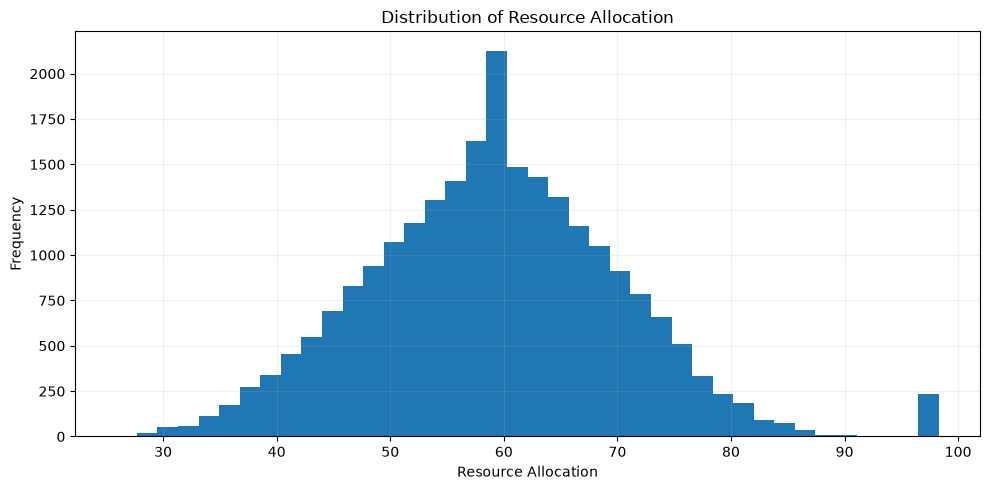

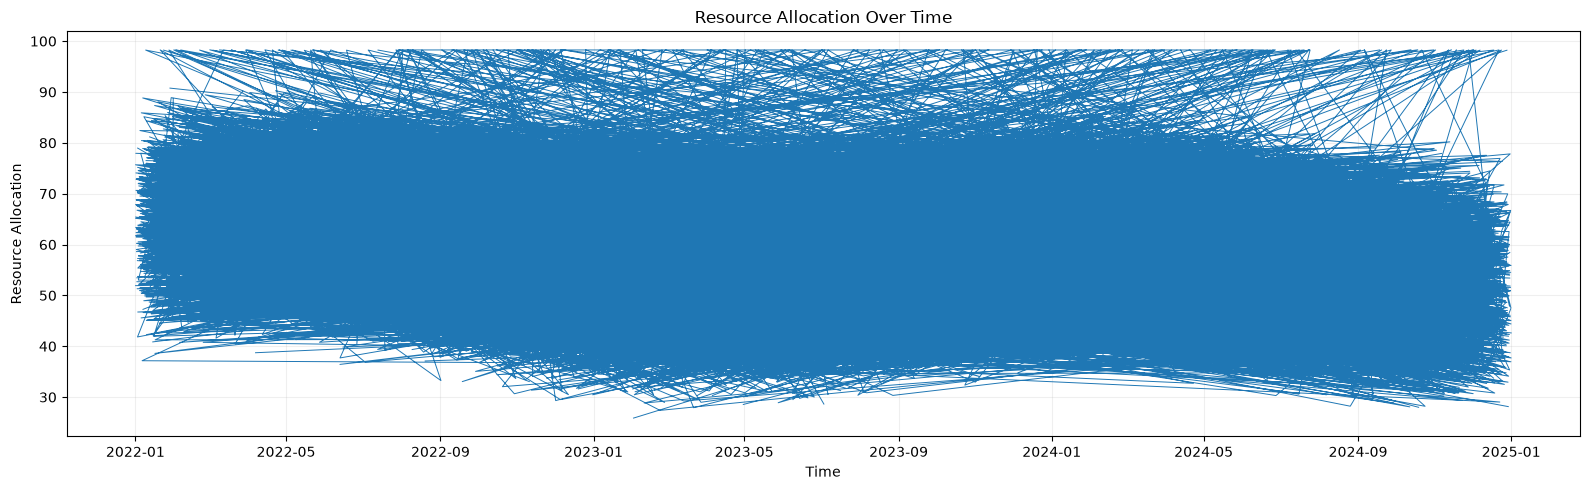


===== DATA QUALITY CHECKS =====
Duplicate timestamps: 0

Most common time gap:
timestamp
0 days 01:00:00    26304
Name: count, dtype: int64

===== STAGE 1 COMPLETE =====


In [1]:
# ==========================================
# STAGE 1: DATA UNDERSTANDING & EDA
# ==========================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ------------------------------------------
# 1. Load Dataset
# ------------------------------------------

data = pd.read_csv("resource_utilization.csv")

# Convert timestamp to datetime
data["timestamp"] = pd.to_datetime(data["timestamp"])

print("===== DATASET OVERVIEW =====")

print(f"Rows    : {data.shape[0]:,}")
print(f"Columns : {data.shape[1]}")

print("\n===== COLUMNS =====")
print(list(data.columns))

print("\n===== DATE RANGE =====")
print("Start:", data["timestamp"].min())
print("End  :", data["timestamp"].max())

print("\n===== DATA TYPES =====")
print(data.dtypes)

# ------------------------------------------
# 2. First Few Rows
# ------------------------------------------

print("\n===== FIRST 5 ROWS =====")
display(data.head())

# ------------------------------------------
# 3. Missing Values
# ------------------------------------------

print("\n===== MISSING VALUES =====")

missing = data.isnull().sum()
missing_percent = (missing / len(data) * 100).round(2)

missing_summary = pd.DataFrame({
    "Missing Count": missing,
    "Missing %": missing_percent
})

display(missing_summary)

# ------------------------------------------
# 4. Summary Statistics
# ------------------------------------------

print("\n===== SUMMARY STATISTICS =====")

display(data.describe().round(2))

# ------------------------------------------
# 5. Target Distribution
# ------------------------------------------

plt.figure(figsize=(10, 5))

plt.hist(
    data["Resource Allocation"].dropna(),
    bins=40
)

plt.title("Distribution of Resource Allocation")
plt.xlabel("Resource Allocation")
plt.ylabel("Frequency")
plt.grid(alpha=0.2)

plt.tight_layout()
plt.show()

# ------------------------------------------
# 6. Resource Allocation Over Time
# ------------------------------------------

plt.figure(figsize=(16, 5))

plt.plot(
    data["timestamp"],
    data["Resource Allocation"],
    linewidth=0.7
)

plt.title("Resource Allocation Over Time")
plt.xlabel("Time")
plt.ylabel("Resource Allocation")
plt.grid(alpha=0.2)

plt.tight_layout()
plt.show()

# ------------------------------------------
# 7. Basic Dataset Quality Checks
# ------------------------------------------

print("\n===== DATA QUALITY CHECKS =====")

print(
    "Duplicate timestamps:",
    data["timestamp"].duplicated().sum()
)

time_diff = data["timestamp"].sort_values().diff()

print("\nMost common time gap:")
print(time_diff.value_counts().head())

print("\n===== STAGE 1 COMPLETE =====")

In [2]:
# ==========================================
# STAGE 2: DATA CLEANING
# ==========================================

# Create a copy of the original dataset
clean_data = data.copy()


# ==========================================
# STEP 2.1 - MISSING VALUE ANALYSIS
# ==========================================

print("===== STEP 2.1: MISSING VALUE ANALYSIS =====")

print("\nMissing values:")
print(clean_data.isnull().sum())

print("\nMissing percentage:")
print((clean_data.isnull().mean() * 100).round(2))


# ==========================================
# STEP 2.2 - HANDLE MISSING VALUES
# ==========================================

print("\n===== STEP 2.2: HANDLING MISSING VALUES =====")

columns_to_fill = [
    "cpu_utilization",
    "memory_usage",
    "storage_usage",
    "Resource Allocation"
]

# Fill missing values using linear interpolation
clean_data[columns_to_fill] = (
    clean_data[columns_to_fill]
    .interpolate(method="linear")
)

print("\nMissing values after interpolation:")
print(clean_data.isnull().sum())


# ==========================================
# STEP 2.3 - CHECK DUPLICATE TIMESTAMPS
# ==========================================

print("\n===== STEP 2.3: DUPLICATE CHECK =====")

duplicate_count = clean_data["timestamp"].duplicated().sum()

print("Duplicate timestamps:", duplicate_count)


# ==========================================
# STEP 2.4 - CHECK FEATURE RANGES
# ==========================================

print("\n===== STEP 2.4: FEATURE RANGE CHECK =====")

features = [
    "cpu_utilization",
    "memory_usage",
    "storage_usage",
    "workload",
    "Resource Allocation"
]

range_check = pd.DataFrame({
    "Minimum": clean_data[features].min(),
    "Maximum": clean_data[features].max(),
    "Mean": clean_data[features].mean()
}).round(2)

display(range_check)


# ==========================================
# STEP 2.5 - FINAL CLEANING CHECK
# ==========================================

print("\n===== STEP 2.5: FINAL CLEANING CHECK =====")

print("Rows:", len(clean_data))
print("Columns:", len(clean_data.columns))

print("\nFinal missing values:")
print(clean_data.isnull().sum())

print("\nDuplicate timestamps:",
      clean_data["timestamp"].duplicated().sum())

print("\n===== STAGE 2 COMPLETE =====")

===== STEP 2.1: MISSING VALUE ANALYSIS =====

Missing values:
timestamp                 0
cpu_utilization        2819
memory_usage           3071
storage_usage          3306
workload                  0
Resource Allocation    2572
dtype: int64

Missing percentage:
timestamp               0.00
cpu_utilization        10.72
memory_usage           11.67
storage_usage          12.57
workload                0.00
Resource Allocation     9.78
dtype: float64

===== STEP 2.2: HANDLING MISSING VALUES =====

Missing values after interpolation:
timestamp              0
cpu_utilization        0
memory_usage           0
storage_usage          0
workload               0
Resource Allocation    0
dtype: int64

===== STEP 2.3: DUPLICATE CHECK =====
Duplicate timestamps: 0

===== STEP 2.4: FEATURE RANGE CHECK =====


,Minimum,Maximum,Mean
cpu_utilization,0.12,156.37,53.18
memory_usage,5.22,94.97,49.92
storage_usage,40.02,109.97,75.05
workload,38.11,272.04,92.49
Resource Allocation,25.87,98.30,59.20



===== STEP 2.5: FINAL CLEANING CHECK =====
Rows: 26305
Columns: 6

Final missing values:
timestamp              0
cpu_utilization        0
memory_usage           0
storage_usage          0
workload               0
Resource Allocation    0
dtype: int64

Duplicate timestamps: 0

===== STAGE 2 COMPLETE =====


In [3]:
# ==========================================
# STAGE 3: FEATURE ENGINEERING
# ==========================================

print("===== STAGE 3: FEATURE ENGINEERING =====")

# ------------------------------------------
# Step 3.0 - Convert timestamp to datetime
# ------------------------------------------

clean_data["timestamp"] = pd.to_datetime(
    clean_data["timestamp"]
)

print("\nTimestamp data type:")
print(clean_data["timestamp"].dtype)


# ------------------------------------------
# Step 3.1 - Extract Hour
# ------------------------------------------

clean_data["hour"] = clean_data["timestamp"].dt.hour


# ------------------------------------------
# Step 3.2 - Extract Day of Week
# Monday = 0, Tuesday = 1, ..., Sunday = 6
# ------------------------------------------

clean_data["day_of_week"] = (
    clean_data["timestamp"].dt.dayofweek
)


# ------------------------------------------
# Step 3.3 - Create Weekend Feature
# ------------------------------------------

clean_data["is_weekend"] = (
    clean_data["day_of_week"] >= 5
).astype(int)


# ------------------------------------------
# Step 3.4 - Display Results
# ------------------------------------------

print("\nNew features created:")
print("- hour")
print("- day_of_week")
print("- is_weekend")

print("\nFirst 10 rows:")
display(clean_data.head(10))


# ------------------------------------------
# Step 3.5 - Final Check
# ------------------------------------------

print("\nDataset shape:", clean_data.shape)

print("\nColumns:")
print(clean_data.columns.tolist())

print("\n===== STAGE 3 COMPLETE =====")

===== STAGE 3: FEATURE ENGINEERING =====

Timestamp data type:
datetime64[us]

New features created:
- hour
- day_of_week
- is_weekend

First 10 rows:


,timestamp,cpu_utilization,memory_usage,storage_usage,workload,Resource Allocation,hour,day_of_week,is_weekend
0,2024-05-15 06:00:00,93.667656,65.739742,81.202149,100.000000,76.398051,6,2,0
1,2022-03-20 00:00:00,79.968970,45.771232,56.178079,96.201530,52.783747,0,6,1
2,2024-03-31 02:00:00,66.270283,85.537221,61.594411,100.000000,71.699889,2,6,1
3,2022-10-05 07:00:00,50.305590,55.492008,100.419747,100.000000,69.456805,7,2,0
4,2022-07-18 08:00:00,58.567954,77.339342,60.446444,100.000000,66.624977,8,0,0
5,2023-09-14 05:00:00,7.462298,52.184884,68.621519,75.666037,46.663221,5,3,0
6,2022-12-12 07:00:00,13.151543,46.509752,100.466308,76.384330,55.942921,7,0,0
7,2022-12-17 03:00:00,54.374813,50.575471,92.316865,99.191858,59.850936,3,5,1
8,2024-08-08 10:00:00,55.418183,54.641189,69.616730,100.000000,60.408061,10,3,0
9,2022-06-18 20:00:00,85.791187,28.175576,60.477309,100.000000,54.167102,20,5,1



Dataset shape: (26305, 9)

Columns:
['timestamp', 'cpu_utilization', 'memory_usage', 'storage_usage', 'workload', 'Resource Allocation', 'hour', 'day_of_week', 'is_weekend']

===== STAGE 3 COMPLETE =====


In [ ]:
# ==========================================
# STAGE 4: TIME-SERIES FORECASTING SETUP
# ==========================================

print("===== STAGE 4: FORECASTING SETUP =====")


# ------------------------------------------
# Step 4.1 - Make sure data is chronological
# ------------------------------------------

clean_data = clean_data.sort_values(
    "timestamp"
).reset_index(drop=True)


# ------------------------------------------
# Step 4.2 - Define features and target
# ------------------------------------------

features = [
    "cpu_utilization",
    "memory_usage",
    "storage_usage",
    "workload",
    "hour",
    "day_of_week",
    "is_weekend"
]

target = "Resource Allocation"


# ------------------------------------------
# Step 4.3 - Chronological Train/Validation/Test Split
# ------------------------------------------

n = len(clean_data)

train_end = int(n * 0.70)
val_end = int(n * 0.85)

train_data = clean_data.iloc[:train_end].copy()

val_data = clean_data.iloc[
    train_end:val_end
].copy()

test_data = clean_data.iloc[
    val_end:
].copy()


# ------------------------------------------
# Step 4.4 - Display dataset sizes
# ------------------------------------------

print("\nDataset split:")

print("Total      :", len(clean_data))
print("Training   :", len(train_data))
print("Validation :", len(val_data))
print("Testing    :", len(test_data))


# ------------------------------------------
# Step 4.5 - Display date ranges
# ------------------------------------------

print("\nDate ranges:")

print(
    "Training   :",
    train_data["timestamp"].min(),
    "→",
    train_data["timestamp"].max()
)

print(
    "Validation :",
    val_data["timestamp"].min(),
    "→",
    val_data["timestamp"].max()
)

print(
    "Testing    :",
    test_data["timestamp"].min(),
    "→",
    test_data["timestamp"].max()
)


# ------------------------------------------
# Step 4.6 - Define sequence length
# ------------------------------------------

sequence_length = 168

print("\nSequence length:", sequence_length)
print("168 hours = 7 days")


# ------------------------------------------
# Final chronological check
# ------------------------------------------

print("\n===== CHRONOLOGICAL CHECK =====")

print(
    "Training ends before validation:",
    train_data["timestamp"].max()
    < val_data["timestamp"].min()
)

print(
    "Validation ends before testing:",
    val_data["timestamp"].max()
    < test_data["timestamp"].min()
)

print("\n===== STAGE 4 COMPLETE =====")

In [ ]:
# ==========================================
# STEP 4.7 - CREATE TIME-SERIES SEQUENCES
# ==========================================

def create_sequences(dataframe, features, target, sequence_length):
    
    X = []
    y = []
    
    feature_values = dataframe[features].values
    target_values = dataframe[target].values
    
    for i in range(sequence_length, len(dataframe)):
        
        # Previous 168 hours
        X.append(
            feature_values[i-sequence_length:i]
        )
        
        # Next hour's Resource Allocation
        y.append(
            target_values[i]
        )
    
    return np.array(X), np.array(y)


# Create training sequences
X_train, y_train = create_sequences(
    train_data,
    features,
    target,
    sequence_length
)

# Create validation sequences
X_val, y_val = create_sequences(
    val_data,
    features,
    target,
    sequence_length
)

# Create testing sequences
X_test, y_test = create_sequences(
    test_data,
    features,
    target,
    sequence_length
)


# ==========================================
# DISPLAY RESULTS
# ==========================================

print("===== SEQUENCE RESULTS =====")

print("\nX_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)

print("\nX_val shape:", X_val.shape)
print("y_val shape:", y_val.shape)

print("\nX_test shape:", X_test.shape)
print("y_test shape:", y_test.shape)

In [ ]:
# ==========================================
# STAGE 5: SCALING
# ==========================================

from sklearn.preprocessing import StandardScaler

print("===== STAGE 5: DATA SCALING =====")


# ------------------------------------------
# Create scalers
# ------------------------------------------

X_scaler = StandardScaler()
y_scaler = StandardScaler()


# ------------------------------------------
# Fit X scaler ONLY on training data
# ------------------------------------------

# X_train shape:
# (samples, 168 hours, 7 features)

X_train_2d = X_train.reshape(
    -1,
    X_train.shape[-1]
)

X_scaler.fit(X_train_2d)


# ------------------------------------------
# Transform all X datasets
# ------------------------------------------

X_train = X_scaler.transform(
    X_train_2d
).reshape(X_train.shape)

X_val = X_scaler.transform(
    X_val.reshape(-1, X_val.shape[-1])
).reshape(X_val.shape)

X_test = X_scaler.transform(
    X_test.reshape(-1, X_test.shape[-1])
).reshape(X_test.shape)


# ------------------------------------------
# Scale target
# ------------------------------------------

y_train = y_train.reshape(-1, 1)
y_val = y_val.reshape(-1, 1)
y_test = y_test.reshape(-1, 1)


# Fit target scaler ONLY on training targets
y_scaler.fit(y_train)

y_train = y_scaler.transform(y_train).ravel()

y_val = y_scaler.transform(y_val).ravel()

y_test = y_scaler.transform(y_test).ravel()


# ------------------------------------------
# Display results
# ------------------------------------------

print("\nScaled shapes:")

print("X_train:", X_train.shape)
print("X_val  :", X_val.shape)
print("X_test :", X_test.shape)

print("\ny_train:", y_train.shape)
print("y_val  :", y_val.shape)
print("y_test :", y_test.shape)

print("\n===== SCALING COMPLETE =====")

In [ ]:
%pip install tensorflow

In [ ]:
# ==========================================
# STAGE 6: BUILD LSTM MODEL
# ==========================================

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout

print("===== STAGE 6: LSTM MODEL =====")


# ------------------------------------------
# Create model
# ------------------------------------------

model = Sequential()


# LSTM layer
model.add(
    LSTM(
        64,
        input_shape=(168, 7)
    )
)


# Dense layer
model.add(
    Dense(
        32,
        activation="relu"
    )
)


# Dropout to reduce overfitting
model.add(
    Dropout(0.2)
)


# Output layer
model.add(
    Dense(
        1,
        activation="linear"
    )
)


# ------------------------------------------
# Compile model
# ------------------------------------------

model.compile(
    optimizer="adam",
    loss="mse",
    metrics=["mae"]
)


# ------------------------------------------
# Display architecture
# ------------------------------------------

model.summary()

print("\n===== MODEL BUILD COMPLETE =====")

In [ ]:
# ==========================================
# STAGE 7: TRAIN LSTM MODEL
# ==========================================

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

print("===== STAGE 7: MODEL TRAINING =====")


# ------------------------------------------
# Build model using modern Input layer
# ------------------------------------------

model = Sequential([
    
    Input(shape=(168, 7)),
    
    LSTM(64),
    
    Dense(32, activation="relu"),
    
    Dropout(0.2),
    
    Dense(1, activation="linear")
])


# ------------------------------------------
# Compile
# ------------------------------------------

model.compile(
    optimizer="adam",
    loss="mse",
    metrics=["mae"]
)


# ------------------------------------------
# Callbacks
# ------------------------------------------

early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

checkpoint = ModelCheckpoint(
    "best_lstm_model.keras",
    monitor="val_loss",
    save_best_only=True
)


# ------------------------------------------
# Train
# ------------------------------------------

history = model.fit(
    X_train,
    y_train,
    validation_data=(X_val, y_val),
    epochs=30,
    batch_size=32,
    callbacks=[
        early_stopping,
        checkpoint
    ],
    verbose=1
)


print("\n===== TRAINING COMPLETE =====")

In [ ]:
print("\n===== TRAINING COMPLETE =====")

In [ ]:
print("\n===== TRAINING COMPLETE =====")

In [ ]:
# ==========================================
# STAGE 8: TEST MODEL ON UNSEEN DATA
# ==========================================

import numpy as np
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

print("===== STAGE 8: MODEL EVALUATION =====")


# ------------------------------------------
# Step 8.1 - Predict on test data
# ------------------------------------------

y_pred_scaled = model.predict(X_test)

# Convert predictions from 2D to 1D
y_pred_scaled = y_pred_scaled.flatten()


# ------------------------------------------
# Step 8.2 - Convert back to original scale
# ------------------------------------------

y_pred = y_scaler.inverse_transform(
    y_pred_scaled.reshape(-1, 1)
).flatten()

y_actual = y_scaler.inverse_transform(
    y_test.reshape(-1, 1)
).flatten()


# ------------------------------------------
# Step 8.3 - Calculate performance metrics
# ------------------------------------------

mae = mean_absolute_error(y_actual, y_pred)

mse = mean_squared_error(y_actual, y_pred)

rmse = np.sqrt(mse)

r2 = r2_score(y_actual, y_pred)


# ------------------------------------------
# Step 8.4 - Display results
# ------------------------------------------

print("\n===== TEST RESULTS =====")

print(f"MAE  : {mae:.4f}")
print(f"MSE  : {mse:.4f}")
print(f"RMSE : {rmse:.4f}")
print(f"R²   : {r2:.4f}")


# ------------------------------------------
# Step 8.5 - Display some predictions
# ------------------------------------------

print("\n===== FIRST 10 PREDICTIONS =====")

for i in range(10):
    print(
        f"{i+1}. Actual: {y_actual[i]:.2f} | "
        f"Predicted: {y_pred[i]:.2f}"
    )


print("\n===== STAGE 8 COMPLETE =====")

In [ ]:
# ==========================================
# STAGE 9: ACTUAL VS PREDICTED VISUALIZATION
# ==========================================

import matplotlib.pyplot as plt

print("===== STAGE 9: VISUALIZATION =====")


# Number of test predictions to display
n = 200


plt.figure(figsize=(15, 6))

plt.plot(
    y_actual[:n],
    label="Actual Resource Allocation"
)

plt.plot(
    y_pred[:n],
    label="Predicted Resource Allocation"
)

plt.title("Actual vs Predicted Resource Allocation")
plt.xlabel("Test Sample")
plt.ylabel("Resource Allocation")
plt.legend()
plt.grid()

plt.show()


print("===== STAGE 9 COMPLETE =====")

In [ ]:
# ==========================================
# STAGE 10: BASELINE MODEL COMPARISON
# ==========================================

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

print("===== STAGE 10: BASELINE VS LSTM =====")


# ------------------------------------------
# Step 10.1 - Calculate training average
# ------------------------------------------

# Convert scaled y_train back to original values
y_train_original = y_scaler.inverse_transform(
    y_train.reshape(-1, 1)
).flatten()

train_mean = np.mean(y_train_original)

print(f"\nTraining Mean Resource Allocation: {train_mean:.2f}")


# ------------------------------------------
# Step 10.2 - Baseline prediction
# ------------------------------------------

# Predict the training mean for every test sample
baseline_pred = np.full(
    len(y_actual),
    train_mean
)


# ------------------------------------------
# Step 10.3 - Evaluate Baseline
# ------------------------------------------

baseline_mae = mean_absolute_error(y_actual, baseline_pred)

baseline_mse = mean_squared_error(y_actual, baseline_pred)

baseline_rmse = np.sqrt(baseline_mse)

baseline_r2 = r2_score(y_actual, baseline_pred)


# ------------------------------------------
# Step 10.4 - Compare Results
# ------------------------------------------

print("\n===== BASELINE RESULTS =====")

print(f"MAE  : {baseline_mae:.4f}")
print(f"MSE  : {baseline_mse:.4f}")
print(f"RMSE : {baseline_rmse:.4f}")
print(f"R²   : {baseline_r2:.4f}")


print("\n===== LSTM RESULTS =====")

print(f"MAE  : {mae:.4f}")
print(f"MSE  : {mse:.4f}")
print(f"RMSE : {rmse:.4f}")
print(f"R²   : {r2:.4f}")


# ------------------------------------------
# Step 10.5 - Final Comparison
# ------------------------------------------

print("\n===== COMPARISON =====")

if rmse < baseline_rmse:
    print("LSTM has a lower RMSE than the baseline.")
    print("→ LSTM performs better than the simple baseline.")
else:
    print("LSTM does NOT beat the baseline.")
    print("→ The current LSTM approach needs improvement.")


print("\n===== STAGE 10 COMPLETE =====")

In [ ]:
# ==========================================
# STAGE 11: RESOURCE ALLOCATION ANALYSIS
# ==========================================

import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

print("===== STAGE 11: RESOURCE ALLOCATION ANALYSIS =====")


# ------------------------------------------
# Step 11.1 - Overall Resource Allocation
# ------------------------------------------

plt.figure(figsize=(15, 5))

plt.plot(
    clean_data["timestamp"],
    clean_data["Resource Allocation"]
)

plt.title("Resource Allocation Over Time")
plt.xlabel("Time")
plt.ylabel("Resource Allocation")

plt.xticks(rotation=45)
plt.grid()

plt.show()


# ------------------------------------------
# Step 11.2 - Hourly Pattern
# ------------------------------------------

hourly_avg = (
    clean_data
    .groupby("hour")["Resource Allocation"]
    .mean()
)

plt.figure(figsize=(12, 5))

plt.plot(
    hourly_avg.index,
    hourly_avg.values,
    marker="o"
)

plt.title("Average Resource Allocation by Hour")
plt.xlabel("Hour of Day")
plt.ylabel("Average Resource Allocation")

plt.xticks(range(24))
plt.grid()

plt.show()


# ------------------------------------------
# Step 11.3 - Daily Pattern
# ------------------------------------------

daily_avg = (
    clean_data
    .groupby("day_of_week")["Resource Allocation"]
    .mean()
)

day_names = [
    "Monday",
    "Tuesday",
    "Wednesday",
    "Thursday",
    "Friday",
    "Saturday",
    "Sunday"
]

plt.figure(figsize=(10, 5))

plt.plot(
    day_names,
    daily_avg.values,
    marker="o"
)

plt.title("Average Resource Allocation by Day")
plt.xlabel("Day")
plt.ylabel("Average Resource Allocation")

plt.xticks(rotation=30)
plt.grid()

plt.show()


# ------------------------------------------
# Step 11.4 - Basic Statistics
# ------------------------------------------

print("\n===== RESOURCE ALLOCATION STATISTICS =====")

print(
    clean_data["Resource Allocation"].describe()
)


print("\n===== STAGE 11 COMPLETE =====")

In [ ]:
# ==========================================
# STAGE 12: 24-HOUR LSTM EXPERIMENT
# ==========================================

import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, Input
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from sklearn.preprocessing import StandardScaler

print("===== STAGE 12: 24-HOUR LSTM EXPERIMENT =====")


# ------------------------------------------
# Step 12.1 - Sequence length
# ------------------------------------------

sequence_length = 24

print(f"\nSequence length: {sequence_length} hours")
print("24 hours = 1 day")


# ------------------------------------------
# Step 12.2 - Select features
# ------------------------------------------

features = [
    "cpu_utilization",
    "memory_usage",
    "storage_usage",
    "workload",
    "hour",
    "day_of_week",
    "is_weekend"
]

target = "Resource Allocation"


# ------------------------------------------
# Step 12.3 - Prepare data
# ------------------------------------------

X_data = clean_data[features].values
y_data = clean_data[target].values


# ------------------------------------------
# Step 12.4 - Create sequences
# ------------------------------------------

X = []
y = []

for i in range(sequence_length, len(clean_data)):

    X.append(
        X_data[i-sequence_length:i]
    )

    y.append(
        y_data[i]
    )

X = np.array(X)
y = np.array(y)


print("\nSequence shapes:")
print("X:", X.shape)
print("y:", y.shape)


# ------------------------------------------
# Step 12.5 - Chronological split
# ------------------------------------------

train_end = int(0.70 * len(X))
val_end = int(0.85 * len(X))

X_train_24 = X[:train_end]
y_train_24 = y[:train_end]

X_val_24 = X[train_end:val_end]
y_val_24 = y[train_end:val_end]

X_test_24 = X[val_end:]
y_test_24 = y[val_end:]


print("\nDataset split:")

print("Training   :", len(X_train_24))
print("Validation :", len(X_val_24))
print("Testing    :", len(X_test_24))


# ------------------------------------------
# Step 12.6 - Scale input features
# ------------------------------------------

x_scaler_24 = StandardScaler()

X_train_24 = x_scaler_24.fit_transform(
    X_train_24.reshape(-1, X_train_24.shape[-1])
).reshape(X_train_24.shape)

X_val_24 = x_scaler_24.transform(
    X_val_24.reshape(-1, X_val_24.shape[-1])
).reshape(X_val_24.shape)

X_test_24 = x_scaler_24.transform(
    X_test_24.reshape(-1, X_test_24.shape[-1])
).reshape(X_test_24.shape)


# ------------------------------------------
# Step 12.7 - Scale target
# ------------------------------------------

y_scaler_24 = StandardScaler()

y_train_24 = y_scaler_24.fit_transform(
    y_train_24.reshape(-1, 1)
).flatten()

y_val_24 = y_scaler_24.transform(
    y_val_24.reshape(-1, 1)
).flatten()

y_test_24_original = y_test_24.copy()

y_test_24 = y_scaler_24.transform(
    y_test_24.reshape(-1, 1)
).flatten()


print("\nScaled shapes:")

print("X_train:", X_train_24.shape)
print("X_val  :", X_val_24.shape)
print("X_test :", X_test_24.shape)


# ------------------------------------------
# Step 12.8 - Build LSTM
# ------------------------------------------

model_24 = Sequential([

    Input(shape=(24, len(features))),

    LSTM(64),

    Dense(32, activation="relu"),

    Dropout(0.2),

    Dense(1)
])


model_24.compile(
    optimizer="adam",
    loss="mse",
    metrics=["mae"]
)


print("\n===== 24-HOUR LSTM MODEL =====")

model_24.summary()


# ------------------------------------------
# Step 12.9 - Callbacks
# ------------------------------------------

checkpoint_24 = ModelCheckpoint(
    "best_lstm_24h.keras",
    monitor="val_loss",
    save_best_only=True
)

early_stop_24 = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)


# ------------------------------------------
# Step 12.10 - Train
# ------------------------------------------

print("\n===== STARTING 24-HOUR TRAINING =====")

history_24 = model_24.fit(
    X_train_24,
    y_train_24,

    validation_data=(
        X_val_24,
        y_val_24
    ),

    epochs=20,

    batch_size=32,

    callbacks=[
        checkpoint_24,
        early_stop_24
    ],

    verbose=1
)


print("\n===== STAGE 12 COMPLETE =====")

In [ ]:
# ==========================================
# STAGE 13: EVALUATE 24-HOUR LSTM
# ==========================================

import numpy as np
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

print("===== STAGE 13: 24-HOUR MODEL EVALUATION =====")


# ------------------------------------------
# Step 13.1 - Predict test data
# ------------------------------------------

y_pred_24_scaled = model_24.predict(X_test_24)

y_pred_24_scaled = y_pred_24_scaled.flatten()


# ------------------------------------------
# Step 13.2 - Convert predictions
# back to original scale
# ------------------------------------------

y_pred_24 = y_scaler_24.inverse_transform(
    y_pred_24_scaled.reshape(-1, 1)
).flatten()


y_actual_24 = y_scaler_24.inverse_transform(
    y_test_24.reshape(-1, 1)
).flatten()


# ------------------------------------------
# Step 13.3 - Calculate metrics
# ------------------------------------------

mae_24 = mean_absolute_error(
    y_actual_24,
    y_pred_24
)

mse_24 = mean_squared_error(
    y_actual_24,
    y_pred_24
)

rmse_24 = np.sqrt(mse_24)

r2_24 = r2_score(
    y_actual_24,
    y_pred_24
)


# ------------------------------------------
# Step 13.4 - Display results
# ------------------------------------------

print("\n===== 24-HOUR LSTM TEST RESULTS =====")

print(f"MAE  : {mae_24:.4f}")
print(f"MSE  : {mse_24:.4f}")
print(f"RMSE : {rmse_24:.4f}")
print(f"R²   : {r2_24:.4f}")


# ------------------------------------------
# Step 13.5 - Sample predictions
# ------------------------------------------

print("\n===== FIRST 10 PREDICTIONS =====")

for i in range(10):

    print(
        f"{i+1}. Actual: {y_actual_24[i]:.2f} | "
        f"Predicted: {y_pred_24[i]:.2f}"
    )


print("\n===== STAGE 13 COMPLETE =====")

In [ ]:
# ==========================================
# STAGE 14: MODEL COMPARISON VISUALIZATION
# ==========================================

import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.models import load_model

print("===== STAGE 14: MODEL COMPARISON =====")


# ------------------------------------------
# Step 14.1 - Load the best 168-hour model
# ------------------------------------------

model_168 = load_model("best_lstm_model.keras")

print("168-hour LSTM model loaded successfully.")


# ------------------------------------------
# Step 14.2 - Generate 168-hour predictions
# ------------------------------------------

pred_168_scaled = model_168.predict(X_test)

pred_168_scaled = pred_168_scaled.flatten()


# ------------------------------------------
# Step 14.3 - Convert predictions
# back to original scale
# ------------------------------------------

pred_168_actual = y_scaler.inverse_transform(
    pred_168_scaled.reshape(-1, 1)
).flatten()


# ------------------------------------------
# Step 14.4 - Convert actual 168-hour
# test values back to original scale
# ------------------------------------------

actual_168 = y_scaler.inverse_transform(
    y_test.reshape(-1, 1)
).flatten()


# ------------------------------------------
# Step 14.5 - 24-hour model values
# ------------------------------------------

actual_24 = y_actual_24.flatten()

pred_24_actual = y_pred_24.flatten()


# ------------------------------------------
# Step 14.6 - Common number of points
# ------------------------------------------

n = min(
    200,
    len(actual_168),
    len(pred_168_actual),
    len(actual_24),
    len(pred_24_actual)
)


# ------------------------------------------
# Step 14.7 - Plot
# ------------------------------------------

plt.figure(figsize=(18, 8))

plt.plot(
    actual_168[:n],
    label="Actual Resource Allocation"
)

plt.plot(
    pred_168_actual[:n],
    label="168-Hour LSTM"
)

plt.plot(
    pred_24_actual[:n],
    label="24-Hour LSTM"
)

plt.title(
    "Resource Allocation Forecasting: "
    "Actual vs 24-Hour vs 168-Hour LSTM"
)

plt.xlabel("Test Time Step")

plt.ylabel("Resource Allocation")

plt.legend()

plt.grid(True)

plt.tight_layout()

plt.show()


# ------------------------------------------
# Step 14.8 - Print information
# ------------------------------------------

print("\n===== VISUALIZATION INFORMATION =====")

print(f"Points plotted: {n}")

print("\nModel RMSE:")

print("Baseline      : 11.2662")
print("168-hour LSTM : 10.4561")
print(f"24-hour LSTM  : {rmse_24:.4f}")

print("\n===== STAGE 14 COMPLETE =====")

In [ ]:
# ==========================================
# STAGE 15: NEXT 24-HOUR FORECAST
# ==========================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from tensorflow.keras.models import load_model
from sklearn.preprocessing import StandardScaler

print("===== STAGE 15: NEXT 24-HOUR FORECAST =====")


# ------------------------------------------
# Step 15.1 - Load best 168-hour model
# ------------------------------------------

model_168 = load_model("best_lstm_model.keras")

print("Best 168-hour LSTM loaded.")


# ------------------------------------------
# Step 15.2 - Features
# ------------------------------------------

features = [
    "cpu_utilization",
    "memory_usage",
    "storage_usage",
    "workload",
    "hour",
    "day_of_week",
    "is_weekend"
]

target = "Resource Allocation"


# ------------------------------------------
# Step 15.3 - Recreate 168-hour sequences
# ------------------------------------------

sequence_length = 168

X_data = clean_data[features].values
y_data = clean_data[target].values

X = []
y = []

for i in range(sequence_length, len(clean_data)):

    X.append(
        X_data[i-sequence_length:i]
    )

    y.append(
        y_data[i]
    )

X = np.array(X)
y = np.array(y)


# ------------------------------------------
# Step 15.4 - Same chronological split
# used for the 168-hour model
# ------------------------------------------

train_end = int(0.70 * len(X))
val_end = int(0.85 * len(X))

X_train_168 = X[:train_end]
y_train_168 = y[:train_end]

X_val_168 = X[train_end:val_end]
y_val_168 = y[train_end:val_end]

X_test_168 = X[val_end:]
y_test_168 = y[val_end:]


# ------------------------------------------
# Step 15.5 - Recreate input scaler
# ------------------------------------------

x_scaler_168 = StandardScaler()

x_scaler_168.fit(
    X_train_168.reshape(
        -1,
        X_train_168.shape[-1]
    )
)


# ------------------------------------------
# Step 15.6 - Recreate target scaler
# ------------------------------------------

y_scaler_168 = StandardScaler()

y_scaler_168.fit(
    y_train_168.reshape(-1, 1)
)


print("\n168-hour scalers recreated.")


# ------------------------------------------
# Step 15.7 - Get latest 168 hours
# ------------------------------------------

future_sequence = clean_data[
    features
].tail(168).values.copy()


print("\nLatest historical window:")
print(future_sequence.shape)

print("168 hours = 7 days")


# ------------------------------------------
# Step 15.8 - Forecast next 24 hours
# ------------------------------------------

future_predictions = []

for step in range(24):

    # Scale the current 168-hour window
    sequence_scaled = x_scaler_168.transform(
        future_sequence
    )

    # Predict next hour
    prediction_scaled = model_168.predict(
        sequence_scaled.reshape(1, 168, 7),
        verbose=0
    )[0][0]

    # Convert prediction back to original scale
    prediction = y_scaler_168.inverse_transform(
        [[prediction_scaled]]
    )[0][0]

    future_predictions.append(prediction)


    # --------------------------------------
    # Create next time-feature row
    # --------------------------------------

    last_row = future_sequence[-1].copy()

    next_hour = int(last_row[4]) + 1

    if next_hour >= 24:
        next_hour = 0

    next_day = int(last_row[5]) + 1

    if next_day >= 7:
        next_day = 0

    next_weekend = 1 if next_day >= 5 else 0


    # Copy latest known values
    next_row = last_row.copy()

    # Update temporal features
    next_row[4] = next_hour
    next_row[5] = next_day
    next_row[6] = next_weekend


    # Add new row
    future_sequence = np.vstack(
        [
            future_sequence,
            next_row
        ]
    )


    # Keep latest 168 hours
    future_sequence = future_sequence[-168:]


# ------------------------------------------
# Step 15.9 - Create forecast table
# ------------------------------------------

last_timestamp = clean_data[
    "timestamp"
].iloc[-1]

future_timestamps = pd.date_range(
    start=last_timestamp + pd.Timedelta(hours=1),
    periods=24,
    freq="h"
)


forecast_df = pd.DataFrame({

    "timestamp": future_timestamps,

    "predicted_resource_allocation":
        future_predictions
})


# ------------------------------------------
# Step 15.10 - Display forecast
# ------------------------------------------

print("\n===== NEXT 24 HOURS FORECAST =====")

print(
    forecast_df.to_string(index=False)
)


# ------------------------------------------
# Step 15.11 - Forecast summary
# ------------------------------------------

print("\n===== FORECAST SUMMARY =====")

print(
    f"Minimum forecast : "
    f"{np.min(future_predictions):.2f}"
)

print(
    f"Maximum forecast : "
    f"{np.max(future_predictions):.2f}"
)

print(
    f"Average forecast : "
    f"{np.mean(future_predictions):.2f}"
)


# ------------------------------------------
# Step 15.12 - Plot forecast
# ------------------------------------------

plt.figure(figsize=(18, 8))

plt.plot(
    future_timestamps,
    future_predictions,
    marker="o",
    label="Forecasted Resource Allocation"
)

plt.title(
    "Next 24 Hours Resource Allocation Forecast"
)

plt.xlabel("Future Time")

plt.ylabel("Resource Allocation")

plt.xticks(rotation=45)

plt.legend()

plt.grid(True)

plt.tight_layout()

plt.show()


print("\n===== STAGE 15 COMPLETE =====")